# 2.4 指数型分布族 (The Exponential Family)

本ノートブックでは、ベルヌーイ分布、二項分布、多項分布、ポアソン分布、ガンマ分布、ガウス分布など、機械学習で頻繁に用いられる多くの確率分布を包括する統一的枠組みである**指数型分布族 (Exponential Family)** について学びます。
最尤推定と十分統計量の関係、一般的な共役事前分布の構成、そして無情報事前分布（Jeffreys事前分布）の理論と計算を扱います。

## 2.4.0 指数型分布族の定義と一般形

確率変数 $\mathbf{x}$ に対するパラメータ $\boldsymbol{\eta}$ の確率密度が以下の形式で表されるとき、この分布族を**指数型分布族**と呼びます。

$$ p(\mathbf{x} | \boldsymbol{\eta}) = h(\mathbf{x}) g(\boldsymbol{\eta}) \exp\{ \boldsymbol{\eta}^T \mathbf{u}(\mathbf{x}) \} $$

あるいは、対数分配関数 $A(\boldsymbol{\eta}) = -\ln g(\boldsymbol{\eta})$ を用いて、
$$ p(\mathbf{x} | \boldsymbol{\eta}) = h(\mathbf{x}) \exp\{ \boldsymbol{\eta}^T \mathbf{u}(\mathbf{x}) - A(\boldsymbol{\eta}) \} $$
とも表されます。

各項の役割：
- $\boldsymbol{\eta}$: **自然パラメータ (Natural parameters)** または正準パラメータ
- $\mathbf{u}(\mathbf{x})$: **十分統計量 (Sufficient statistics)** のベクトル
- $g(\boldsymbol{\eta})$: 確率の総和/全積分を 1 にするための規格化係数（分配関数の逆数）
- $h(\mathbf{x})$: 基底測度 (Base measure)

### 例1: ベルヌーイ分布の指数型表現
ベルヌーイ分布 $p(x|\mu) = \mu^x (1-\mu)^{1-x}$ は以下のように変形できます。
$$ p(x|\mu) = \exp\{ x \ln \mu + (1-x) \ln(1-\mu) \} = (1-\mu) \exp\left\{ \ln\left(\frac{\mu}{1-\mu}\right) x \right\} $$
これにより、
- 自然パラメータ: $\eta = \ln\left(\frac{\mu}{1-\mu}\right)$ （ロジット関数） $\iff \mu = \sigma(\eta) = \frac{1}{1 + e^{-\eta}}$ （ロジスティック・シグモイド関数）
- 十分統計量: $u(x) = x$
- $h(x) = 1$
- $g(\eta) = (1 + e^\eta)^{-1}$

### 例2: 1次元ガウス分布の指数型表現
$$ p(x|\mu, \sigma^2) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left\{ -\frac{1}{2\sigma^2} x^2 + \frac{\mu}{\sigma^2} x - \frac{\mu^2}{2\sigma^2} \right\} $$
これにより、
- $\boldsymbol{\eta} = \begin{pmatrix} \mu / \sigma^2 \\ -1 / (2\sigma^2) \end{pmatrix}$
- $\mathbf{u}(x) = \begin{pmatrix} x \\ x^2 \end{pmatrix}$
十分統計量が $x$ と $x^2$ であることが自然に示されます。

## 2.4.1 最尤推定と十分統計量 (Maximum Likelihood & Sufficient Statistics)

確率の規格化条件 $\int p(\mathbf{x}|\boldsymbol{\eta}) d\mathbf{x} = 1$ の両辺を自然パラメータ $\boldsymbol{\eta}$ について偏微分します。
$$ \nabla g(\boldsymbol{\eta}) \int h(\mathbf{x}) \exp\{ \boldsymbol{\eta}^T \mathbf{u}(\mathbf{x}) \} d\mathbf{x} + g(\boldsymbol{\eta}) \int h(\mathbf{x}) \exp\{ \boldsymbol{\eta}^T \mathbf{u}(\mathbf{x}) \} \mathbf{u}(\mathbf{x}) d\mathbf{x} = 0 $$
第1項に $\int p(\mathbf{x}|\boldsymbol{\eta}) d\mathbf{x} = \frac{1}{g(\boldsymbol{\eta})}$ を代入して整理すると、**対数分配関数の勾配が十分統計量の期待値に厳密に一致する**という極めて美しい関係が得られます。

$$ -\nabla \ln g(\boldsymbol{\eta}) = \nabla A(\boldsymbol{\eta}) = \mathbb{E}[\mathbf{u}(\mathbf{x})] $$

### 最尤推定量
独立な観測データ $\mathcal{D} = \{\mathbf{x}_1, \dots, \mathbf{x}_N\}$ に対する対数尤度関数は
$$ \ln p(\mathcal{D} | \boldsymbol{\eta}) = N \ln g(\boldsymbol{\eta}) + \boldsymbol{\eta}^T \left( \sum_{n=1}^N \mathbf{u}(\mathbf{x}_n) \right) + \sum_{n=1}^N \ln h(\mathbf{x}_n) $$
これを $\boldsymbol{\eta}$ で微分して 0 と置くと、
$$ -\nabla \ln g(\boldsymbol{\eta}_{\mathrm{ML}}) = \frac{1}{N} \sum_{n=1}^N \mathbf{u}(\mathbf{x}_n) $$

すなわち、**最尤推定量 $\boldsymbol{\eta}_{\mathrm{ML}}$ は、十分統計量の理論的期待値が標本平均と一致するように選ばれる**ことが分かります。
データサイズ $N$ がどれほど巨大であっても、データセット全体から $\sum_{n=1}^N \mathbf{u}(\mathbf{x}_n)$ という固定次元のベクトルさえ計算・保存しておけば、全データを破棄しても最尤解を完全に再現できるという**十分統計量の定理**の数学的根拠がここにあります。

## 2.4.2 共役事前分布の一般的構成 (Conjugate Priors)

任意の指数型分布族 $p(\mathbf{x}|\boldsymbol{\eta}) = h(\mathbf{x}) g(\boldsymbol{\eta}) \exp\{\boldsymbol{\eta}^T \mathbf{u}(\mathbf{x})\}$ に対し、その共役事前分布は必ず以下の形式で構成できます。

$$ p(\boldsymbol{\eta} | \boldsymbol{\chi}, \nu) = f(\boldsymbol{\chi}, \nu) g(\boldsymbol{\eta})^\nu \exp\{ \nu \boldsymbol{\eta}^T \boldsymbol{\chi} \} $$

ここで $\nu$ と $\boldsymbol{\chi}$ はハイパーパラメータです。
サイズ $N$ のデータセット $\mathcal{D}$ を観測したときの事後分布は、
$$ p(\boldsymbol{\eta} | \mathcal{D}, \boldsymbol{\chi}, \nu) \propto p(\mathcal{D} | \boldsymbol{\eta}) p(\boldsymbol{\eta} | \boldsymbol{\chi}, \nu) \propto g(\boldsymbol{\eta})^{\nu + N} \exp\left\{ \boldsymbol{\eta}^T \left( \nu \boldsymbol{\chi} + \sum_{n=1}^N \mathbf{u}(\mathbf{x}_n) \right) \right\} $$
となり、事前分布と全く同一の関数形を保ちます。ハイパーパラメータの更新規則は単なる足し算です。
$$ \nu_{\mathrm{post}} = \nu + N, \quad \boldsymbol{\chi}_{\mathrm{post}} = \frac{\nu \boldsymbol{\chi} + \sum_{n=1}^N \mathbf{u}(\mathbf{x}_n)}{\nu + N} $$

## 2.4.3 無情報事前分布と Jeffreys 事前分布

事前の知識や先入観が全くない状況において、推論結果に偏りを与えない客観的な事前分布を**無情報事前分布 (Noninformative Prior)** と呼びます。

### 1. 移動パラメータ (Location Parameter)
密度関数が $p(x - \mu)$ のように変数の差のみに依存する場合、原点をどこに設定しても事前分布は不変であるべきです（平行移動不変性: $p(\mu) = p(\mu - c)$）。
この要件を満たすのは**一様分布 (Uniform distribution)** です。
$$ p(\mu) = \mathrm{const} $$
（実数全体では積分が発散する変格事前分布 (improper prior) ですが、事後分布は適切に規格化されます。）

### 2. 尺度パラメータ (Scale Parameter)
密度関数が $\frac{1}{\sigma} f(\frac{x}{\sigma})$ のようにスケールに依存する場合、測定単位（cm か m か）に依存しないべきです（拡大縮小不変性: $p(\sigma)d\sigma = p(s\sigma)d(s\sigma)$）。
この要件を満たす事前分布は対数に対して一様な分布です。
$$ p(\sigma) \propto \frac{1}{\sigma} \quad (\iff p(\ln \sigma) = \mathrm{const}) $$

### 3. Jeffreys 事前分布 (Jeffreys Prior)
パラメータ $\theta$ を任意の単調な非線形関数 $\phi = h(\theta)$ で再パラメータ化しても、推論結果が数学的に等価となる不変事前分布です。
フィッシャー情報量
$$ I(\theta) = -\mathbb{E}_x\left[ \frac{\partial^2 \ln p(x|\theta)}{\partial \theta^2} \right] $$
を用いて、Jeffreys 事前分布は以下で定義されます。
$$ p(\theta) \propto \sqrt{|I(\theta)|} $$
変数変換に対して $I(\phi) = I(\theta) (d\theta / d\phi)^2$ となるため、$p(\phi) = p(\theta) |d\theta / d\phi|$ が恒等的に成立し、**パラメータの表記法によらない完全な不変性**を持ちます。

Plot saved to: result/fig2_exponential_family_moments.png


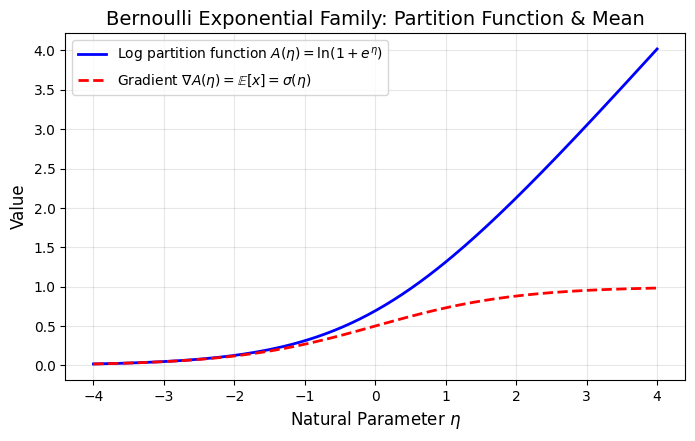

Plot saved to: result/fig2_jeffreys_prior.png


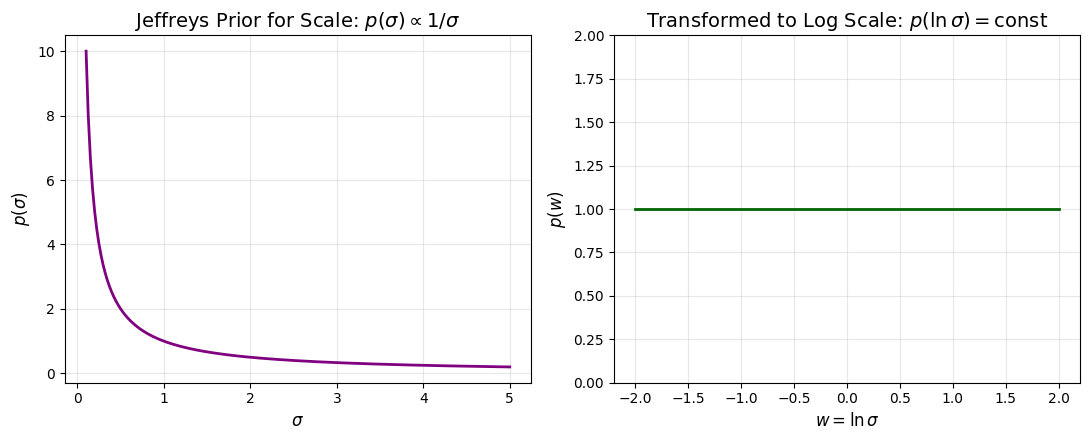

In [1]:
import sys, os
sys.path.append(os.path.abspath('../'))
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from common.plot_utils import save_plot, setup_style
setup_style()

# 1. ベルヌーイ分布の対数分配関数 A(eta) の導出と十分統計量のモーメントの数値的検証
# A(eta) = ln(1 + e^eta), dA/deta = e^eta / (1 + e^eta) = sigma(eta) = E[x]
eta_vals = np.linspace(-4, 4, 200)
A_vals = np.log(1.0 + np.exp(eta_vals))
dA_deta = np.exp(eta_vals) / (1.0 + np.exp(eta_vals))

fig, ax1 = plt.subplots(figsize=(8, 4.5))
ax1.plot(eta_vals, A_vals, 'b-', label=r'Log partition function $A(\eta) = \ln(1+e^\eta)$', lw=2)
ax1.plot(eta_vals, dA_deta, 'r--', label=r'Gradient $\nabla A(\eta) = \mathbb{E}[x] = \sigma(\eta)$', lw=2)
ax1.set_title('Bernoulli Exponential Family: Partition Function & Mean')
ax1.set_xlabel(r'Natural Parameter $\eta$')
ax1.set_ylabel('Value')
ax1.grid(True, alpha=0.3)
ax1.legend()
save_plot(fig, 'result', 'fig2_exponential_family_moments.png')
plt.show()

# 2. 尺度母数に対する Jeffreys 事前分布の不変性の検証
# ガウス分布 N(x | 0, sigma^2) の尺度パラメータ sigma に対するフィッシャー情報量は I(sigma) = 2 / sigma^2
# したがって Jeffreys 事前分布は p(sigma) ~ 1/sigma
# 変数変換 w = ln(sigma) を行うと、p(w) = p(sigma) * |dsigma/dw| = (1/sigma) * sigma = 1 (一様)
sigmas = np.linspace(0.1, 5, 200)
p_sigma = 1.0 / sigmas

w_vals = np.linspace(-2, 2, 200)
p_w = np.ones_like(w_vals)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
ax1.plot(sigmas, p_sigma, 'purple', lw=2)
ax1.set_title(r'Jeffreys Prior for Scale: $p(\sigma) \propto 1/\sigma$')
ax1.set_xlabel(r'$\sigma$')
ax1.set_ylabel(r'$p(\sigma)$')
ax1.grid(True, alpha=0.3)

ax2.plot(w_vals, p_w, 'darkgreen', lw=2)
ax2.set_title(r'Transformed to Log Scale: $p(\ln \sigma) = \mathrm{const}$')
ax2.set_xlabel(r'$w = \ln \sigma$')
ax2.set_ylabel(r'$p(w)$')
ax2.set_ylim(0, 2)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
save_plot(fig, 'result', 'fig2_jeffreys_prior.png')
plt.show()